Starting BFGS optimization on 25 early points...
BFGS finished.
Initial guess from BFGS: a=4.3278, b=2.7154, e=-2.3060, alpha=0.3933, beta=0.7586

Curve-fit results:
E     = 0.099672
A     = 75.890979
alpha = 0.393417
B     = 15.110967
beta  = 0.758561
0.00920220641253895
0.009132361686324553
0.008782778411482048
0.008872806962209394
0.00888546601265747


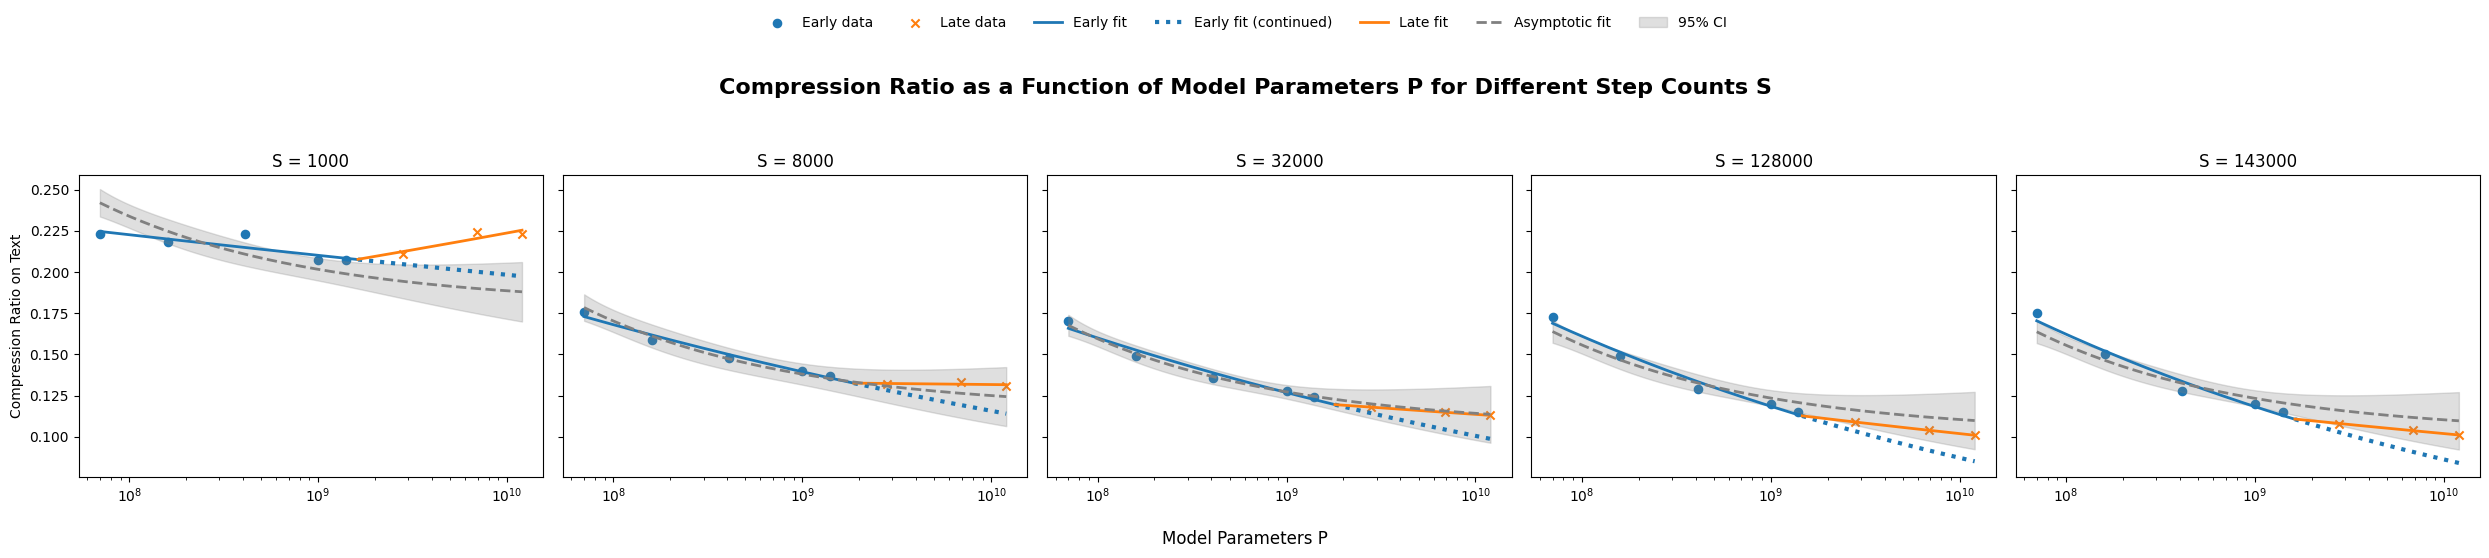


R^2 scores:
Early (fit, 25 points):        R^2 = 0.9655
Late (extrapolation):          R^2 = 0.8886
All points (diagnostic only):  R^2 = 0.9331


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, curve_fit

# =========================
# 1. Load CSV
# =========================
df = pd.read_csv("text_results.csv")
df = df[~df["model"].str.startswith("OLMo")]

# =========================
# 2. Parse model size
# =========================
def parse_size(s):
    size = s.split("-")[1]
    if size.endswith("m"):
        return float(size[:-1]) * 1e6
    if size.endswith("b"):
        return float(size[:-1]) * 1e9
    raise ValueError(f"Unrecognized size: {s}")

df["P"] = df["model"].apply(parse_size)

# =========================
# 3. Parse training steps
# =========================
df["S"] = df["training_step"].str.replace("step ", "", regex=False).astype(int)
df["metric"] = df["compression_ratio"]

# =========================
# 4. Pivot to grid
# =========================
pivot = df.pivot(index="S", columns="P", values="metric")
steps = pivot.index.values
P = pivot.columns.values
metric = pivot.values  # shape (n_steps, n_models)

# =========================
# 5. Model function (Kaplan-style)
# =========================
def asymp_model_2d(P_val, S_val, a, b, e, alpha, beta):
    """metric = exp(e) + exp(a) * P^-alpha + exp(b) * S^-beta"""
    return np.exp(e) + np.exp(a) * P_val**(-alpha) + np.exp(b) * S_val**(-beta)

# =========================
# 6. Only fit first 5 points (early)
# =========================
n_early = 5
fit_idx = np.arange(n_early)
extra_idx = np.arange(n_early, len(P))

P_fit = P[fit_idx]
metric_fit = metric[:, fit_idx]

# Flatten for BFGS
P_grid, S_grid = np.meshgrid(P_fit, steps)
ydata_bfgs = metric_fit.ravel()

def objective(x):
    a, b, e, alpha, beta = x
    pred = asymp_model_2d(*np.meshgrid(P_fit, steps), a, b, e, alpha, beta)
    return np.sum((pred - metric_fit)**2)

# -------------------------
# 6a. BFGS initialization
# -------------------------
x0 = [
    np.log(0.5),              # a ~ log(A)
    np.log(0.5),              # b ~ log(B)
    np.log(metric_fit.min()),  # e ~ log(E)
    0.3,                       # alpha
    0.3                        # beta
]

print("Starting BFGS optimization on 25 early points...")
res_bfgs = minimize(objective, x0, method="BFGS", options=dict(maxiter=2000))
a0, b0, e0, alpha0, beta0 = res_bfgs.x
print("BFGS finished.")
print(f"Initial guess from BFGS: a={a0:.4f}, b={b0:.4f}, e={e0:.4f}, alpha={alpha0:.4f}, beta={beta0:.4f}")

# =========================
# 7. Use curve_fit with BFGS initial guess
# =========================
def curve_model(X, a, b, e, alpha, beta):
    P_val, S_val = X
    return asymp_model_2d(P_val, S_val, a, b, e, alpha, beta).ravel()

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1.0 - ss_res / ss_tot

xdata = np.vstack((np.meshgrid(P_fit, steps)[0].ravel(),
                   np.meshgrid(P_fit, steps)[1].ravel()))

ydata = metric_fit.ravel()

popt, pcov = curve_fit(curve_model, xdata, ydata,
                       p0=[a0, b0, e0, alpha0, beta0])

# Extract parameters
a, b, e, alpha, beta = popt
print("\nCurve-fit results:")
print(f"E     = {np.exp(e):.6f}")
print(f"A     = {np.exp(a):.6f}")
print(f"alpha = {alpha:.6f}")
print(f"B     = {np.exp(b):.6f}")
print(f"beta  = {beta:.6f}")

# =========================
# 8. Plot early/late + asymptotic + confidence band
# =========================
def fit_loglog(x, y):
    m, b = np.polyfit(np.log(x), np.log(y), 1)
    return m, b

P_line = np.logspace(np.log10(P.min()), np.log10(P.max()), 400)

def asymp_with_confidence(P_line, S_val, popt, pcov, n_sigma=1.96):
    a, b, e, alpha, beta = popt
    y = asymp_model_2d(P_line, S_val, a, b, e, alpha, beta)

    J = np.zeros((len(P_line), 5))
    J[:, 0] = np.exp(a) * P_line**(-alpha)       # d/da
    J[:, 1] = np.exp(b) * S_val**(-beta)         # d/db
    J[:, 2] = np.exp(e)                           # d/de
    J[:, 3] = -np.exp(a) * P_line**(-alpha) * np.log(P_line)  # d/dalpha
    J[:, 4] = -np.exp(b) * S_val**(-beta) * np.log(S_val)     # d/dbeta

    var = np.einsum("ij,jk,ik->i", J, pcov, J)
    std = np.sqrt(np.maximum(var, 0))
    print(np.max(std))
    return y, y - n_sigma*std, y + n_sigma*std

fig, axes = plt.subplots(1, len(steps), figsize=(25,5), sharey=True)

for i, S_val in enumerate(steps):
    ax = axes[i]
    y = metric[i]

    m_early, b_early = fit_loglog(P[fit_idx], y[fit_idx])
    m_late, b_late = fit_loglog(P[extra_idx], y[extra_idx])

    # Intersection
    log_P_int = (b_late - b_early) / (m_early - m_late)
    P_int = np.exp(log_P_int)

    mask_early = P_line <= P_int
    mask_late = P_line >= P_int

    y_early = np.exp(b_early) * P_line**m_early
    y_late = np.exp(b_late) * P_line[mask_late]**m_late

    # Asymptotic + confidence
    y_asymp, y_lo, y_hi = asymp_with_confidence(P_line, S_val, popt, pcov)

    # Scatter
    ax.scatter(P[fit_idx], y[fit_idx], color="C0", s=35, label="Early data")
    ax.scatter(P[extra_idx], y[extra_idx], color="C1", s=35, marker="x", label="Late data")

    # Early fits
    ax.plot(P_line[mask_early], y_early[mask_early], color="C0", lw=2, label="Early fit")
    ax.plot(P_line[mask_late], y_early[mask_late], color="C0", lw=3, ls=":", label="Early fit (continued)")

    # Late fit
    ax.plot(P_line[mask_late], y_late, color="C1", lw=2, label="Late fit")

    # Asymptotic + CI
    ax.plot(P_line, y_asymp, color="gray", lw=2, ls="--", label="Asymptotic fit")
    ax.fill_between(P_line, y_lo, y_hi, color="gray", alpha=0.25, label="95% CI")

    ax.set_xscale("log")
    ax.set_title(f"S = {S_val}")

axes[0].set_ylabel("Compression Ratio on Text")
fig.supxlabel("Model Parameters P")


# ---- GLOBAL LEGEND (deduplicated) ----
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # removes duplicates

fig.legend(
    by_label.values(),
    by_label.keys(),
    loc="upper center",
    bbox_to_anchor=(0.5, 1.10),
    ncol=7,
    frameon=False
)

fig.suptitle(
    "Compression Ratio as a Function of Model Parameters P for Different Step Counts S",
    x=0.5,
    y=0.95,      # below legend at 1.10
    fontsize=16,
    weight="bold"
)

# Reserve space for legend
fig.tight_layout(rect=[0, 0, 1, 0.90])

fig.savefig("text.png", dpi=300, bbox_inches="tight")

plt.show()

# =========================
# 9. R^2 calculations
# =========================

# --- Early points (fit domain)
P_early_grid, S_early_grid = np.meshgrid(P[fit_idx], steps)
y_early_true = metric[:, fit_idx].ravel()
y_early_pred = asymp_model_2d(
    P_early_grid, S_early_grid, a, b, e, alpha, beta
).ravel()

r2_early = r2_score(y_early_true, y_early_pred)

# --- Late points (extrapolation)
if len(extra_idx) > 0:
    P_late_grid, S_late_grid = np.meshgrid(P[extra_idx], steps)
    y_late_true = metric[:, extra_idx].ravel()
    y_late_pred = asymp_model_2d(
        P_late_grid, S_late_grid, a, b, e, alpha, beta
    ).ravel()
    r2_late = r2_score(y_late_true, y_late_pred)
else:
    r2_late = np.nan

# --- All points (diagnostic only)
P_all_grid, S_all_grid = np.meshgrid(P, steps)
y_all_true = metric.ravel()
y_all_pred = asymp_model_2d(
    P_all_grid, S_all_grid, a, b, e, alpha, beta
).ravel()

r2_all = r2_score(y_all_true, y_all_pred)

print("\nR^2 scores:")
print(f"Early (fit, 25 points):        R^2 = {r2_early:.4f}")
print(f"Late (extrapolation):          R^2 = {r2_late:.4f}")
print(f"All points (diagnostic only):  R^2 = {r2_all:.4f}")

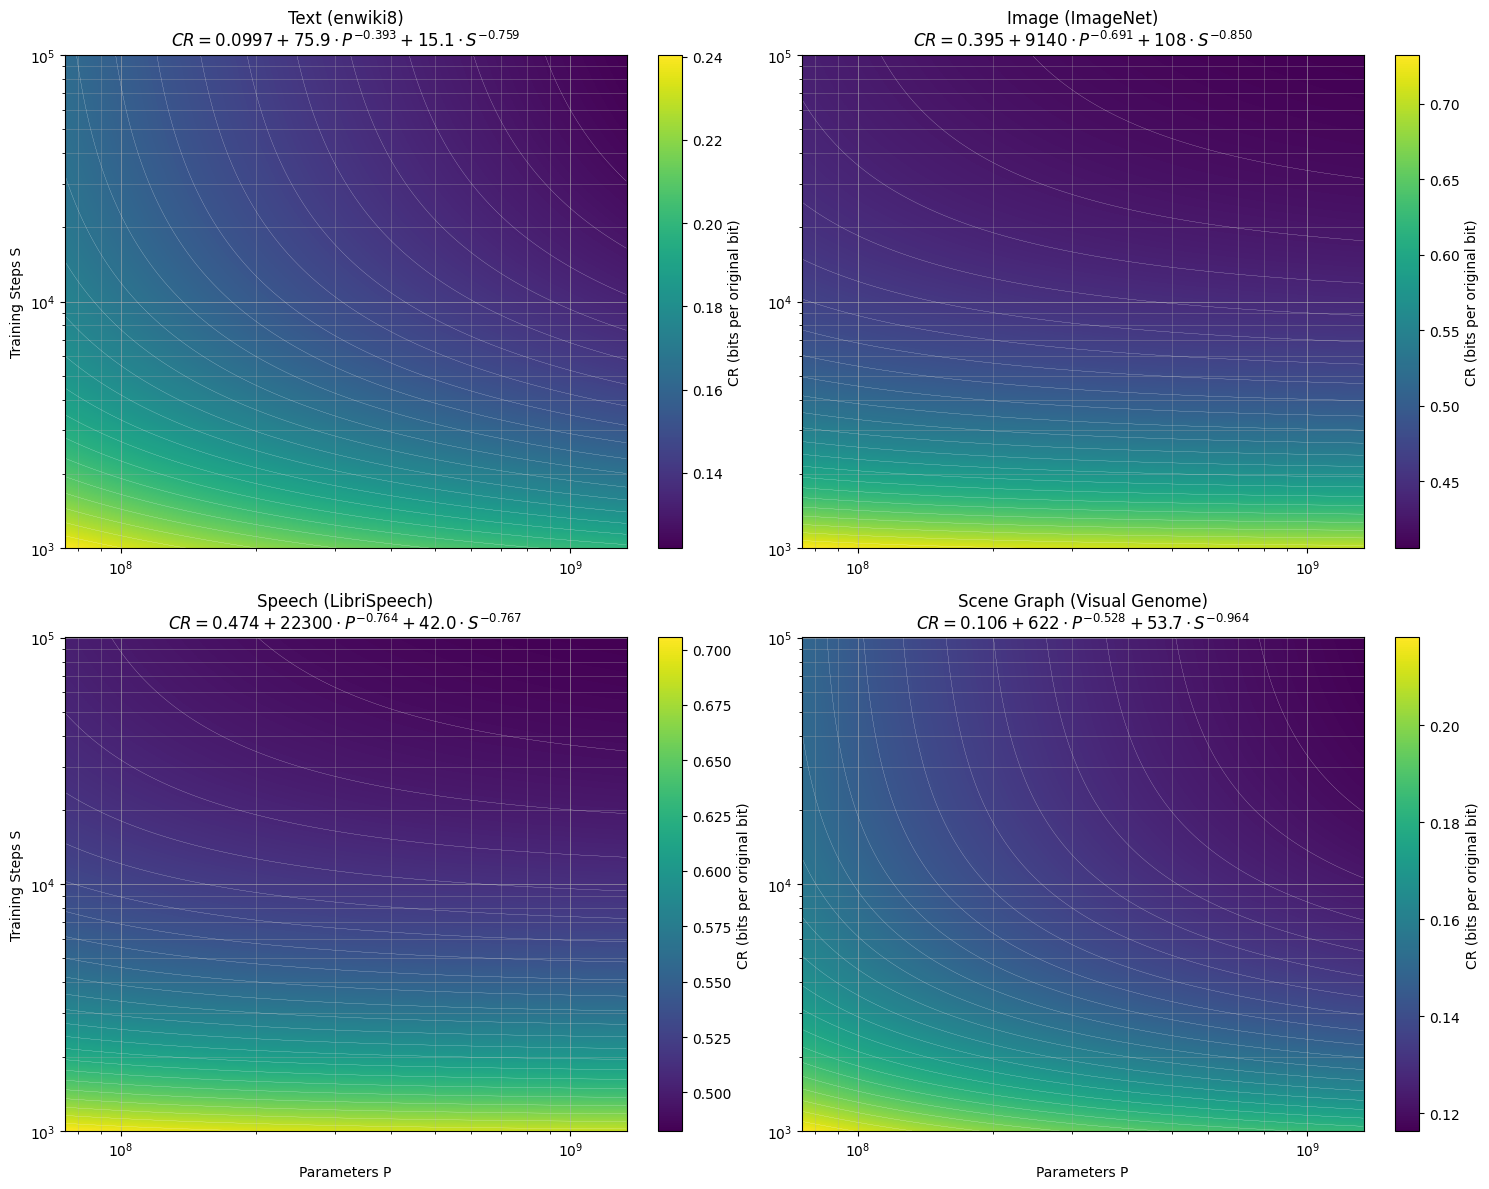

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# Grid
p = np.logspace(7.875, 9.125, 1000)
s = np.logspace(3, 5, 1000)
P, S = np.meshgrid(p, s)

# Modalities
modalities = [
    "Text (enwiki8)",
    "Image (ImageNet)",
    "Speech (LibriSpeech)",
    "Scene Graph (Visual Genome)",
]

# Parameters
a     = [0.0997, 0.395, 0.474, 0.106, 0.517]
b     = [75.9, 9140, 22300, 622, 30.0]
alpha = [0.393, 0.691, 0.764, 0.528, 0.350]
c     = [15.1, 108, 42.0, 53.7, 22.9]
beta  = [0.759, 0.850, 0.767, 0.964, 0.745]

# Figure: 2 × 2 GridSpec
fig = plt.figure(figsize=(15, 12))
gs = gridspec.GridSpec(2, 2, figure=fig)

axes = [
    fig.add_subplot(gs[0, 0]),  # top left
    fig.add_subplot(gs[0, 1]),  # top right
    fig.add_subplot(gs[1, 0]),  # bottom left
    fig.add_subplot(gs[1, 1]),  # bottom right
]

# Plot each modality
for i, ax in enumerate(axes):
    title = modalities[i]
    CR = a[i] + b[i] * P**(-alpha[i]) + c[i] * S**(-beta[i])

    pcm = ax.pcolormesh(P, S, CR, shading="auto", cmap="viridis")
    levels = np.logspace(np.log10(CR.min()), np.log10(CR.max()), 25)
    ax.contour(P, S, CR, levels=levels, colors="white", linewidths=0.125)

    eqn = rf"$CR = {a[i]} + {b[i]}\cdot P^{{-{alpha[i]:.3f}}} + {c[i]}\cdot S^{{-{beta[i]:.3f}}}$"
    ax.set_title(f"{title}\n{eqn}", fontsize=12)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.minorticks_on()
    ax.grid(True, which="major", linewidth=0.5, alpha=0.8)
    ax.grid(True, which="minor", linewidth=0.5, alpha=0.4)

    # Individual colorbar
    cbar = fig.colorbar(pcm, ax=ax, fraction=0.045, pad=0.05)
    cbar.set_label("CR (bits per original bit)")

# Axis labels (outer only)
for ax in axes[2:]:
    ax.set_xlabel("Parameters P")
for ax in axes[0::2]:
    ax.set_ylabel("Training Steps S")

plt.tight_layout()

fig.savefig("scaling_laws.png", dpi=300, bbox_inches="tight")

plt.show()


